# Preparação e análise de Dados em Python #

Nesta aula, aprenderemos um pouco a como entender melhor um conjunto de dados. Nos tempos atuais, é cada vez mais fácil conseguir quantidades cada vez maiores de dados. Contudo, isto vem com um custo: quanto mais dados, mais difícil é de __entender__ os mesmos.

Hoje, aprenderemos a utilizar a biblioteca Pandas para manipular dados.

In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
#!pip3 install pandas --user

Na aula de hoje, usaremos uma base de dados sobre número de vendas de jogos de videogame até 2016. Nosso objetivo é entender melhor os dados para na sequência produzir modelos de regressão que melhor prevejam os números de vendas. Baixe o arquivo que está no Colabweb e coloque-o descomprimido na mesma pasta em que está rodando este notebook:

In [2]:
vg = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')

O Pandas é uma biblioteca de manipulação de dados. A função read_csv lê __todo__ conteúdo do arquivo e coloca em uma estrutura de dados. Existem funções similares para diversos tipos de arquivos, como `xls` e `json`.

Agora vamos visualizar o conteúdo dos nossos dados. Para isto, usaremos a função head, que mostra os 5 primeiros registros:

In [3]:
vg.head()
#vg.tail()
#vg.sample(5)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
vg.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [5]:
vg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       7590 non-null   float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.0+ MB


Acessando os dados de um jogo especifico:

In [6]:
vg.loc[130]
#vg.loc[[1,5,10,20]]

Name               The Elder Scrolls V: Skyrim
Platform                                   PS3
Year_of_Release                         2011.0
Genre                             Role-Playing
Publisher                   Bethesda Softworks
NA_Sales                                  2.55
EU_Sales                                   2.6
JP_Sales                                  0.25
Other_Sales                                1.0
Global_Sales                              6.41
Critic_Score                              92.0
Critic_Count                              16.0
User_Score                                 6.4
User_Count                              2527.0
Developer                Bethesda Game Studios
Rating                                       M
Name: 130, dtype: object

Podemos também acessar colunas especificas através dos seus nomes:

In [7]:
vg[['Name','Critic_Score']]
#vg.Global_Sales

,Name,Critic_Score
0,Wii Sports,76.0
1,Super Mario Bros.,NaN
2,Mario Kart Wii,82.0
3,Wii Sports Resort,80.0
4,Pokemon Red/Pokemon Blue,NaN
...,...,...
16714,Samurai Warriors: Sanada Maru,NaN
16715,LMA Manager 2007,NaN
16716,Haitaka no Psychedelica,NaN
16717,Spirits & Spells,NaN


Quantos jogos para cada sistema nós temos?

In [8]:
vg.Developer.value_counts()

Developer
Ubisoft                                   204
EA Sports                                 172
EA Canada                                 167
Konami                                    162
Capcom                                    139
                                         ... 
Genki, Kojima Productions                   1
Warner Bros. Interactive Entertainment      1
THQ, Altron                                 1
Netherock Ltd.                              1
Interchannel-Holon                          1
Name: count, Length: 1696, dtype: int64

Contando a quantidade de valores diferentes de um atributo numérico:

In [9]:
vg.Critic_Score.value_counts()

Critic_Score
70.0    256
71.0    254
75.0    245
78.0    240
73.0    238
       ... 
20.0      3
21.0      1
17.0      1
22.0      1
13.0      1
Name: count, Length: 82, dtype: int64

Muito né? melhor seria colocar em categorias:

In [10]:
b = list(range(0,100,10))
vg.Critic_Score.value_counts(bins=b)


(70.0, 80.0]      2344
(60.0, 70.0]      1949
(80.0, 90.0]      1518
(50.0, 60.0]      1188
(40.0, 50.0]       571
(30.0, 40.0]       236
(20.0, 30.0]        63
(10.0, 20.0]        11
(-0.001, 10.0]       0
Name: count, dtype: int64

O Pandas oferece vários métodos para entender melhor os dados com estatísticas básicas:

In [11]:
vg.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,7.125046,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,1.500006,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,6.400000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.500000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,8.200000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.700000,10665.000000


Epa! Tem um jogo com lançamento em 2020! Não pode, pois a base é de jogos lançados até 2016. Na verdade, isso é super comum com dados reais, de haver sujeira na base de dados.

E agora, como podemos identificar que jogo é esse ?

In [80]:
vg[vg.Year_of_Release == 2020]

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
5936,Imagine: Makeup Artist,DS,2020.0,Simulation,Ubisoft,0.27,0.0,0.0,0.02,0.29,NaN,NaN,NaN,NaN,Ubisoft,E


Conseguiu entender como funcionou? Brinque um pouco com os dados para entender melhor.

Quais são os jogos mais recentes da base para Nintendo Wii?

In [12]:
vg[vg.Platform=='Wii'].sort_values(['JP_Sales'],ascending = False).head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
13,Wii Fit,Wii,2007.0,Sports,Nintendo,8.92,8.03,3.60,2.15,22.70,80.0,63.0,7.7,146.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E


A saída de boa parte de comandos em Pandas gera objetos do tipo dataframe ou series. Estes objetos novos podem ser utilizados com outras funções pandas, em cascata.

Isto são condições compostas

Jogos de PS3 que tiveram mais do que 20 críticas ordenados pela nota da critica:

In [13]:
vg[(vg.Platform=='PS2') & (vg.Critic_Count>20)].sort_values(['Critic_Score']).head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
12012,McFarlane's Evil Prophecy,PS2,NaN,Action,Konami Digital Entertainment,0.03,0.03,0.0,0.01,0.07,34.0,28.0,3.2,5.0,Konami,M
5337,Charlie and the Chocolate Factory,PS2,2005.0,Adventure,Global Star,0.17,0.13,0.0,0.04,0.35,35.0,21.0,4.1,28.0,"High Voltage Software, Backbone Entertainment",E
7982,Fight Club,PS2,2004.0,Fighting,Vivendi Games,0.09,0.07,0.0,0.02,0.18,36.0,28.0,4.4,22.0,Genuine Games,M
1230,The Simpsons Skateboarding,PS2,2002.0,Sports,Electronic Arts,0.36,0.90,0.0,0.27,1.52,38.0,21.0,5.0,26.0,The Code Monkeys,T
3449,Terminator 3: Rise of the Machines,PS2,2003.0,Action,Atari,0.28,0.22,0.0,0.07,0.58,38.0,21.0,6.3,23.0,Black Ops Entertainment,T


Exercício:


1 - Gere uma base vg2, contendo todos os jogos lançados de 2000 a 2016 e a descreva com describe

2 - Mostre todos os jogos lançados até o ano 2000 onde as vendas japonesas foram acima das americanas, ordenado por vendas globais

3 - Conte, para cada plataforma, quantos jogos com nota de usuário acima de 8 cada uma tem

In [70]:
vg2 = vg[(vg.Year_of_Release>2000) & (vg.Year_of_Release>2016)]
vg2.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,4.00,4.0000,4.0,4.000000,4.000,4.000000,0.0,0.0,0.0,0.0
mean,2017.75,0.0675,0.0,0.015000,0.005,0.087500,NaN,NaN,NaN,NaN
std,1.50,0.1350,0.0,0.017321,0.010,0.135739,NaN,NaN,NaN,NaN
min,2017.00,0.0000,0.0,0.000000,0.000,0.010000,NaN,NaN,NaN,NaN
25%,2017.00,0.0000,0.0,0.007500,0.000,0.010000,NaN,NaN,NaN,NaN
50%,2017.00,0.0000,0.0,0.010000,0.000,0.025000,NaN,NaN,NaN,NaN
75%,2017.75,0.0675,0.0,0.017500,0.005,0.102500,NaN,NaN,NaN,NaN
max,2020.00,0.2700,0.0,0.040000,0.020,0.290000,NaN,NaN,NaN,NaN


In [63]:
vg[(vg.Year_of_Release<2000) & (vg.JP_Sales>vg.NA_Sales)].sort_values(['Global_Sales'],ascending = False).head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
65,Final Fantasy VII,PS,1997.0,Role-Playing,Sony Computer Entertainment,3.01,2.47,3.28,0.96,9.72,92.0,20.0,9.2,1282.0,SquareSoft,T
76,Super Mario Kart,SNES,1992.0,Racing,Nintendo,3.54,1.24,3.81,0.18,8.76,NaN,NaN,NaN,NaN,NaN,NaN
88,Final Fantasy VIII,PS,1999.0,Role-Playing,SquareSoft,2.28,1.72,3.63,0.23,7.86,90.0,24.0,8.6,644.0,SquareSoft,T
137,Street Fighter II: The World Warrior,SNES,1992.0,Fighting,Capcom,2.47,0.83,2.87,0.12,6.30,NaN,NaN,NaN,NaN,NaN,NaN
151,Resident Evil 2,PS,1998.0,Action,Virgin Interactive,1.88,1.47,2.02,0.45,5.82,89.0,13.0,9.2,364.0,Capcom,M


In [82]:
vg[vg.User_Score>8].Platform.value_counts()

Platform
PS2     590
XB      275
PC      237
GC      164
X360    148
Wii     137
PS3     136
GBA     122
DS      116
PSP     100
PS       97
PSV      43
PS4      41
3DS      39
WiiU     21
XOne     21
DC       11
Name: count, dtype: int64

### Usando pandas para plotar com pyplot ###

Uma coisa legal no pandas é que ele é integrado ao pyplot/matplotlib.

Exemplo: Qual a relação entre as vendas globais e a nota da crítica?

<Axes: xlabel='Critic_Score', ylabel='NA_Sales'>

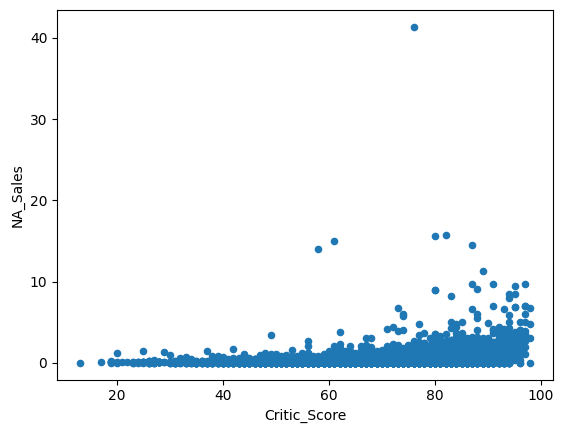

In [14]:
vg.plot(kind='scatter',x='Critic_Score',y='NA_Sales')

Os valores muito altos (como o Wii Sports com 80 milhões de cópias), estão dificultando a visualização. Para resolver este problema, podemos ou eliminar estes valores do plot ou plotar em escala logaritmica:

<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

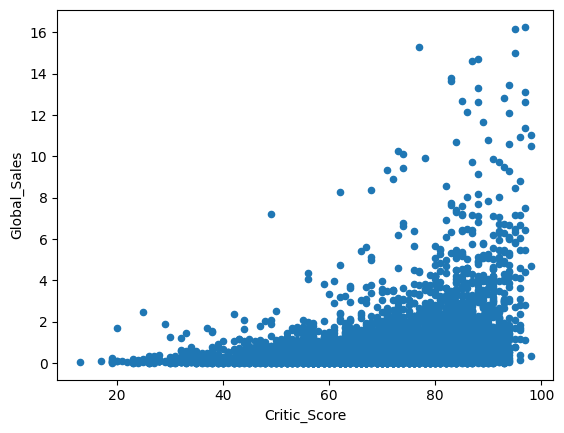

In [15]:
vg[vg.Global_Sales<20].plot(kind='scatter',x='Critic_Score',y='Global_Sales')

#vg.plot(kind='scatter',x='Critic_Score',y='Global_Sales',logy=True)

### Outras correlações mais sofisticadas ###

Como será a comparação entre as notas dos críticos para RPGs em comparação com jogos de corrida?

<Axes: >

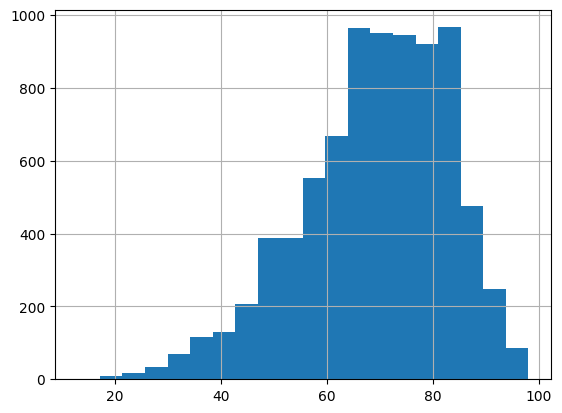

In [16]:
# Primeiro veremos o histograma global
vg.Critic_Score.hist(bins = 20)

<Axes: >

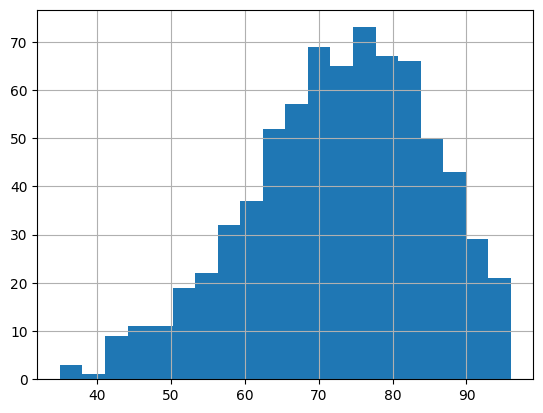

In [17]:
#Agora apenas dos RPGs
vg[vg.Genre=='Role-Playing'].Critic_Score.hist(bins = 20)

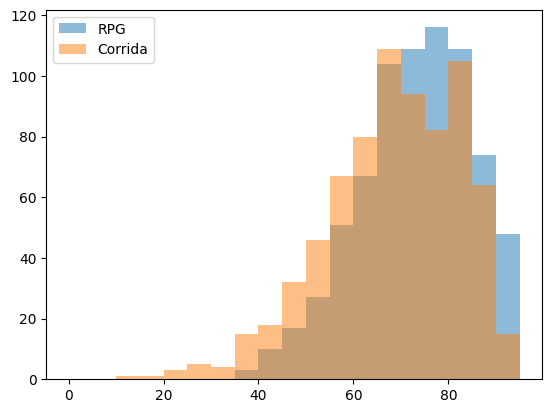

In [18]:
# Podemos comparar os RPGs com os jogos de corrida

bins = list(range(0,100,5))
vgval = vg[vg.Critic_Score.notnull()] # Remover os jogos sem valor de Critic_Score

plt.hist(vgval[vgval.Genre=='Role-Playing'].Critic_Score,bins,alpha=0.5,label='RPG')
plt.hist(vgval[vgval.Genre=='Racing'].Critic_Score,bins,alpha=0.5,label='Corrida')
plt.legend()


E se eu quiser comparar variáveis categóricas?

Vamos analisar duas: Gênero e Plataforma.

In [19]:
pd.crosstab(vg.Platform,vg.Genre,margins = True)

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy,All
Platform,,,,,,,,,,,,,
2600,61,2,2,5,9,11,6,0,24,1,12,0,133
3DO,0,1,0,0,0,1,0,0,0,1,0,0,3
3DS,188,38,14,54,28,20,11,88,7,31,26,15,520
DC,3,11,12,0,2,0,6,4,3,1,10,0,52
DS,340,238,36,391,91,236,67,200,42,284,148,79,2152
GB,6,5,0,8,19,15,2,21,1,5,9,7,98
GBA,167,38,23,110,142,41,64,73,40,18,88,18,822
GC,101,20,42,36,73,13,63,27,48,12,110,11,556
GEN,3,2,5,1,7,0,1,3,1,0,3,1,27


E se a gente quisesse esses valores em porcentagens? Podemos então aplicar uma __função lambda__ nos dados:

In [20]:
pd.crosstab(vg.Platform,vg.Genre,margins = True,normalize='index')*100#.apply(lambda v:100*v/v[-1],axis = 1)

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
2600,45.864662,1.503759,1.503759,3.759398,6.766917,8.270677,4.511278,0.000000,18.045113,0.751880,9.022556,0.000000
3DO,0.000000,33.333333,0.000000,0.000000,0.000000,33.333333,0.000000,0.000000,0.000000,33.333333,0.000000,0.000000
3DS,36.153846,7.307692,2.692308,10.384615,5.384615,3.846154,2.115385,16.923077,1.346154,5.961538,5.000000,2.884615
DC,5.769231,21.153846,23.076923,0.000000,3.846154,0.000000,11.538462,7.692308,5.769231,1.923077,19.230769,0.000000
DS,15.799257,11.059480,1.672862,18.169145,4.228625,10.966543,3.113383,9.293680,1.951673,13.197026,6.877323,3.671004
GB,6.122449,5.102041,0.000000,8.163265,19.387755,15.306122,2.040816,21.428571,1.020408,5.102041,9.183673,7.142857
GBA,20.316302,4.622871,2.798054,13.381995,17.274939,4.987835,7.785888,8.880779,4.866180,2.189781,10.705596,2.189781
GC,18.165468,3.597122,7.553957,6.474820,13.129496,2.338129,11.330935,4.856115,8.633094,2.158273,19.784173,1.978417
GEN,11.111111,7.407407,18.518519,3.703704,25.925926,0.000000,3.703704,11.111111,3.703704,0.000000,11.111111,3.703704


E se eu quiser uma tabela dessas, mas apenas contendo os jogos que venderam mais de 10 milhões de unidades?

In [21]:
pd.crosstab(vg[vg.Global_Sales>10].Platform,vg[vg.Global_Sales>10].Genre,margins = True,normalize='index')

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports
Platform,,,,,,,,,,,
3DS,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.250000,0.500000,0.000000,0.000000,0.000000
DS,0.100000,0.000000,0.000000,0.100000,0.200000,0.100000,0.100000,0.200000,0.000000,0.200000,0.000000
GB,0.000000,0.166667,0.000000,0.000000,0.166667,0.166667,0.000000,0.500000,0.000000,0.000000,0.000000
GBA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
N64,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NES,0.000000,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000
PS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
PS2,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.000000,0.000000
PS3,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000,0.142857,0.000000,0.571429,0.000000,0.000000


## Tabelas Pivo ##

Muitas vezes, queremos cruzar dados de formas mais complexas. A tabela pivo ajuda muito nisso.


Exemplo: Quem teve os melhores RPGs e adventures de acordo com a crítica? O primeiro ou o segundo Playstation?

In [22]:
rpgs = vg[(vg.Platform.isin(['PS2','PS']))& vg.Genre.isin(['Role-Playing','Adventure']) ]
rpgs.head()
pivot = rpgs.pivot_table(values=['Critic_Score'],index = ['Platform','Genre'],aggfunc = ["mean",])
pivot

mean
                      Critic_Score
Platform Genre                    
PS       Adventure       58.000000
         Role-Playing    79.428571
PS2      Adventure       62.348837
         Role-Playing    71.639344

<Axes: ylabel='Platform,Genre'>

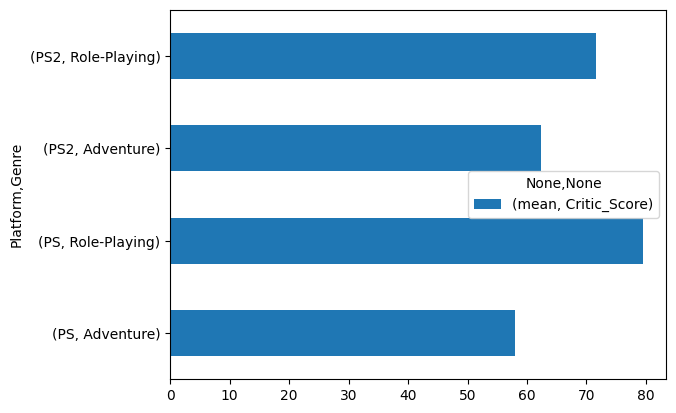

In [23]:
pivot.plot(kind='barh')

Exercício:

Faça uma tabela contendo a media das notas de usuários dos jogos das Publishers Capcom e Activision de acordo com o Rating

<Axes: ylabel='Publisher,Rating'>

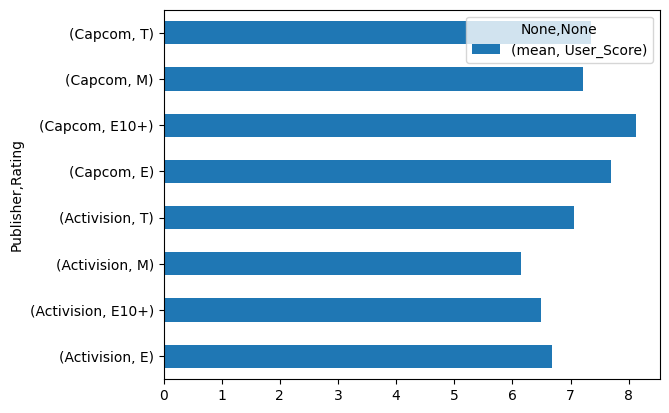

In [83]:
target_publishers = vg[vg.Publisher.isin(['Capcom', 'Activision'])]
pivot_publishers = target_publishers.pivot_table(values=['User_Score'], index=['Publisher', 'Rating'], aggfunc=['mean'])
pivot_publishers.plot(kind='barh')  

E se eu quiser saber quantas unidades o jogo mais vendido de cada plataforma vendeu?

                  max
         Global_Sales
Platform             
PCFX             0.03
GG               0.04
3DO              0.06
TG16             0.14
NG               0.25
WS               0.51
SCD              1.50
SAT              1.93
PSV              1.96
DC               2.42
GEN              6.03
GC               7.07
WiiU             7.09
XOne             7.39
PSP              7.69
2600             7.81
PC               8.01
XB               8.49
PS              10.95
N64             11.89
3DS             14.60
PS4             14.63
GBA             15.85
SNES            20.61
PS2             20.81
PS3             21.04
X360            21.81
DS              29.80
GB              31.37
NES             40.24
Wii             82.53


<Axes: ylabel='Platform'>

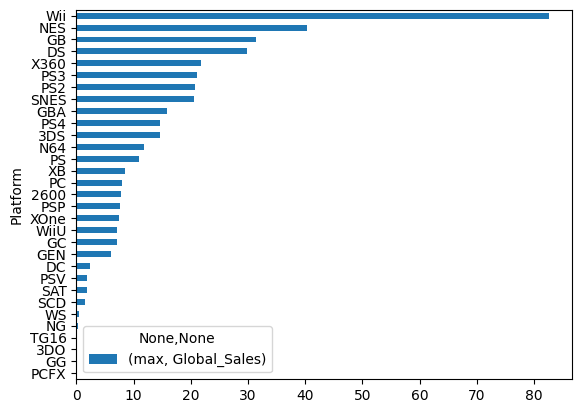

In [96]:
pivot_games = vg.pivot_table(values=['Global_Sales'], index=['Platform'], aggfunc=['max',]).sort_values(by=[('max', 'Global_Sales')], ascending=True)
print(pivot_games)
pivot_games.plot(kind='barh')  

## Agrupando ##

Você pode usar o comando groupby para gerar novas bases de dados modificadas. Por exemplo, você pode tentar prever as vendas totais de plataformas ao invés de jogos individuais. Contudo, para você utilizar os dados agrupados, você deve usar uma função de agregação (sum,count, min,max, mean, etc).

### Exemplo ###

Criando um agrupamento por plataforma

In [24]:
vgplat = vg.groupby(['Platform'])
vgplat.Global_Sales.sum()

Platform
2600      97.08
3DO        0.10
3DS      259.09
DC        15.97
DS       807.10
GB       255.45
GBA      318.50
GC       199.36
GEN       30.78
GG         0.04
N64      218.88
NES      251.07
NG         1.44
PC       260.30
PCFX       0.03
PS       730.68
PS2     1255.64
PS3      939.43
PS4      314.23
PSP      294.30
PSV       54.12
SAT       33.59
SCD        1.87
SNES     200.05
TG16       0.16
WS         1.42
Wii      908.13
WiiU      82.16
X360     971.63
XB       258.26
XOne     159.44
Name: Global_Sales, dtype: float64

Fazendo uma regressão para descobrir total de vendas de um console pelo total de jogos lançados para ele:

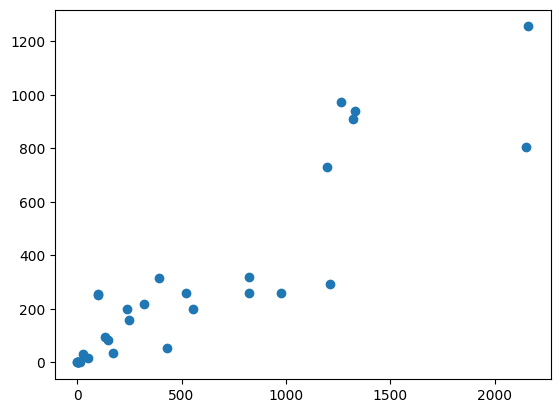

In [25]:
x = vgplat.Name.count()
y = vgplat.Global_Sales.sum()
plt.scatter(x,y)

<Axes: xlabel='Platform'>

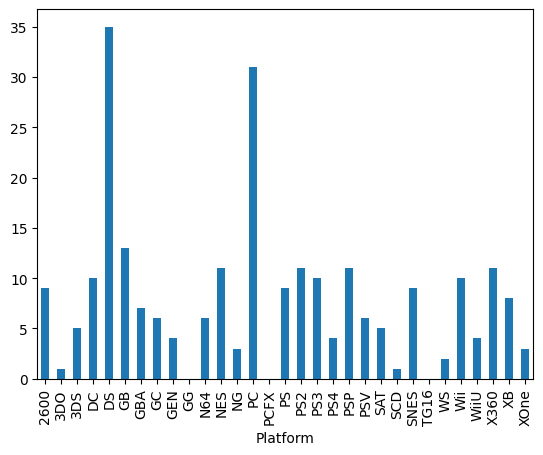

In [26]:
#Total de anos que um console teve jogos

anos = vgplat.Year_of_Release.max() - vgplat.Year_of_Release.min()
anos.plot(kind='bar')

Vocês poderiam usar a informação de ano para ponderar alguma outra informação usada na regressão por exemplo. Contudo, tem algo estranho né? O Nintendo DS está com 35 anos de jogos lançados. Vocês conseguem descobrir o porquê?

<Axes: xlabel='Year_of_Release'>

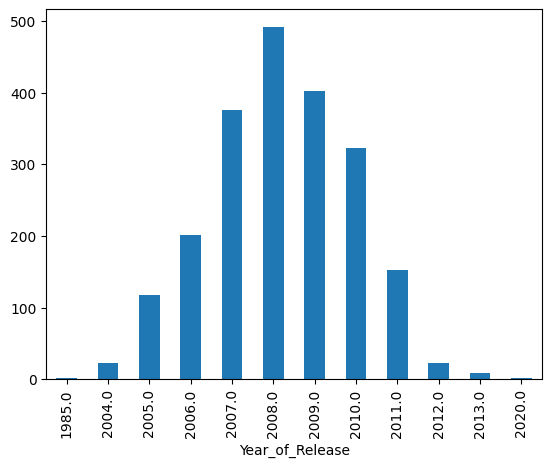

In [49]:
vg[vg.Platform.isin(['DS'])].Year_of_Release.value_counts().sort_index().plot(kind='bar')

In [ ]:
vg[(vg.Platform.isin(['DS']))& (vg.Year_of_Release.isin([1985]))]

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
15959,Strongest Tokyo University Shogi DS,DS,1985.0,Action,Mycom,0.0,0.0,0.02,0.0,0.02,NaN,NaN,NaN,NaN,NaN,NaN


Existe um jogo de DS (Strongest Tokyo University Shogi DS A.K.A "Saikyou Toudai Shogi DSi") cujo ano de lançamento está incorreto, deveria ser 2007